In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [96]:
df = pd.read_pickle("../outputs/cleaned_data.pkl")

In [97]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday


## Top 10 pays par chiffre d'affaires

In [98]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [99]:
plt.close('all')

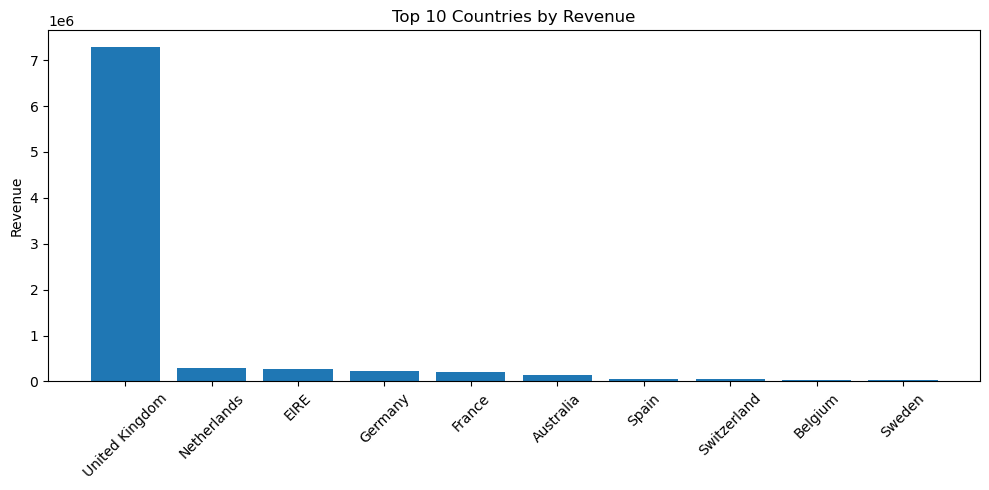

In [100]:
#Graphique
plt.figure(figsize=(10,5))

plt.bar(country_revenue.index, country_revenue.values)

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visuals/top_10_countries.png", bbox_inches='tight')

plt.show()

In [78]:
country_revenue.to_csv("../outputs/country_revenue.csv")

## Top produits

In [79]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

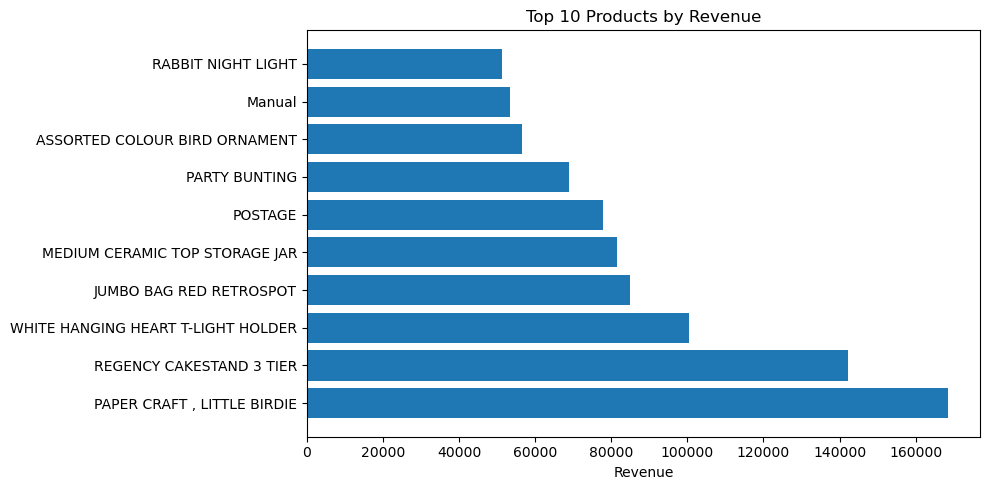

In [80]:
plt.figure(figsize=(10,5))
plt.barh(top_products.index, top_products.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")

plt.tight_layout()

plt.savefig("../visuals/top_10_products.png", bbox_inches='tight')

plt.show()

## Top clients

In [81]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

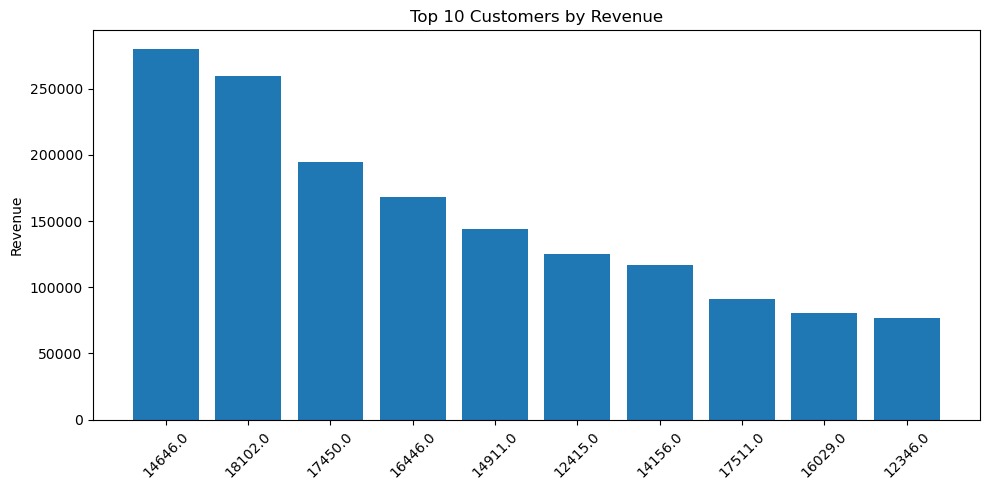

In [82]:
plt.figure(figsize=(10,5))
plt.bar(top_customers.index.astype(str), top_customers.values)

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/top_10_customers.png", bbox_inches='tight')

plt.show()

## Analyse RFM

In [83]:
# Date de référence
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [84]:
# Calcul RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [85]:
def safe_qcut(series, q):
    return pd.qcut(series, q=q, labels=False, duplicates='drop') + 1

rfm['R_score'] = safe_qcut(rfm['Recency'], 4)
rfm['F_score'] = safe_qcut(rfm['Frequency'], 4)
rfm['M_score'] = safe_qcut(rfm['Monetary'], 4)

In [86]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [87]:
# Segmentation
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_score'] == 4:
        return 'Loyal'
    elif row['F_score'] == 4:
        return 'Frequent'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

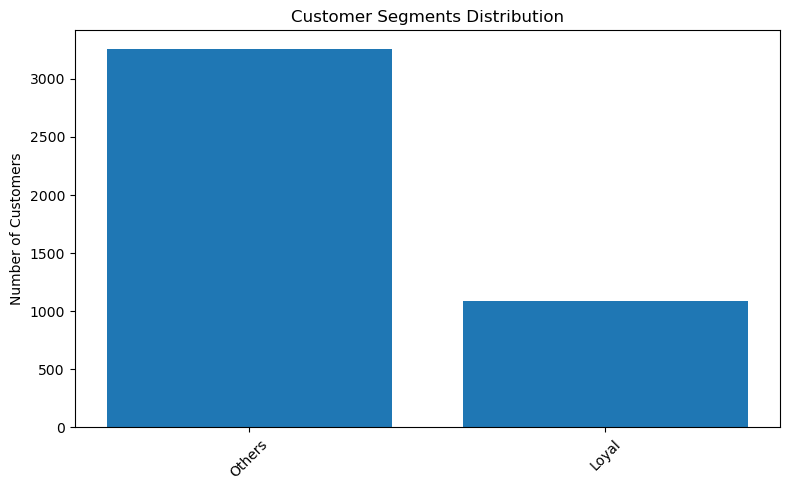

In [88]:
# Distribution des segments
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Segments Distribution")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/top_10_customerSD.png", bbox_inches='tight')

plt.show()

## Evolution du chiffre d'affaires dans le temps

In [89]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

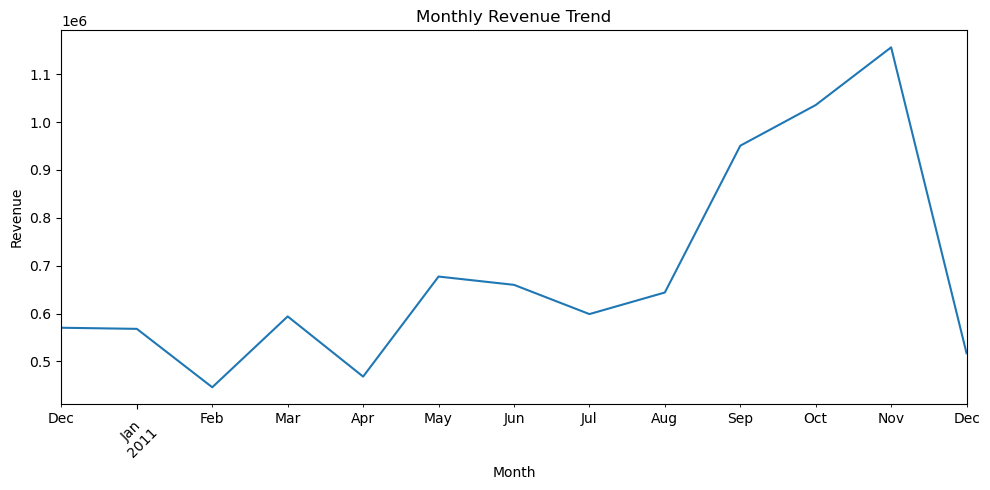

In [90]:
# Visualisation
plt.figure(figsize=(10,5))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visuals/monthly_Revenue_Trend.png", bbox_inches='tight')

plt.show()

## Analyse par jours de la semaine

In [92]:
df['Day'] = df['InvoiceDate'].dt.day_name()

daily_revenue = df.groupby('Day')['Revenue'].sum()

daily_revenue = daily_revenue.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

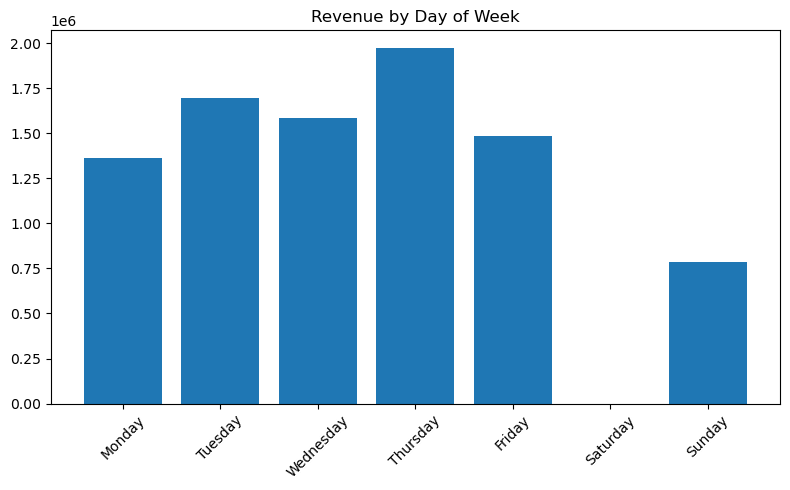

In [93]:
# Graph
plt.figure(figsize=(8,5))
plt.bar(daily_revenue.index, daily_revenue.values)

plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visuals/revenue_by_day_of_week.png", bbox_inches='tight')

plt.show()

In [94]:
df.to_pickle("../outputs/cleaned_data.pkl")